# Análisis Exploratorio de Datos

In [1]:
import os
import pandas as pd
import langdetect
import spacy
from sklearn.feature_extraction.text import CountVectorizer

# Parámetros

In [2]:
# Paths
path_interim = os.path.join("data", "interim")

# Input
file_input = "prep.csv"

# Cargar datos

In [3]:
path_data_eda = os.path.join(path_interim, file_input)

df_eda = pd.read_csv(path_data_eda)
df_eda.head()

,x_text,y_is_nf
0,Poder crear un usuario y acceder a través de é...,1
1,Poder crear un perfil personal e individual a ...,0
2,Acceder a la aplicación y a sus funcionalidade...,1
3,Todos los datos introducidos podrán ser leídos...,1
4,"Poder leer, eliminar, editar o incluir cualqui...",0


# Verificar idioma del corpus

In [4]:
# Aplicar a cada ejemplo de `x_text` de `df_eda` la función apropiada de `langdetect`
# no todas las instancias pueden ser detectadas como español, dado que la herramienta no es perfecta
df_eda['lang'] = df_eda['x_text'].apply(lambda x: langdetect.detect(x))

In [5]:
# Contar valores en porcentaje para `df_eda['lang']`
print(df_eda['lang'].value_counts())
print(f"\nPorcentaje:\n{df_eda['lang'].value_counts(normalize=True) * 100}")

lang
es    383
pt      4
ca      1
it      1
Name: count, dtype: int64

Porcentaje:
lang
es    98.457584
pt     1.028278
ca     0.257069
it     0.257069
Name: proportion, dtype: float64


# Frecuencia del vocabulario

In [6]:
# Celda auxiliar
from unidecode import unidecode
import typing

# Cargar modelo de idioma español
nlp = spacy.load('es_core_news_lg')


def tokenizer_lemma_es(text,
                       max_input_len=nlp.max_length,  # 1000000
                       min_token_len= 2,
                       ) -> typing.List[str]:
    doc = nlp(text[:max_input_len])  # truncar el documento de entrada al máximo proporcionado por el modelo de spacy
    lemmas = [unidecode(token.lemma_) for token in doc if token.is_alpha
              and len(token) > min_token_len
              and not token.is_stop
              and not token.like_email
              and not token.like_url
              and not token.is_currency
              and token.ent_type_ not in ['PER', 'LOC', 'ORG']
              ]
    return lemmas # list[str]


example = df_eda.loc[0, "x_text"]
ex_lemma = tokenizer_lemma_es(example)

print(f"{example=}")
print(f"{ex_lemma=}")

# Deberías ver:
# example='Poder crear un usuario y acceder a través de él a la aplicación'
# ex_lemma=['crear', 'usuario', 'acceder', 'aplicacion']


example='Poder crear un usuario y acceder a través de él a la aplicación'
ex_lemma=['crear', 'usuario', 'acceder', 'aplicacion']


In [7]:
cvect_lemma = CountVectorizer(  
    # Usa la correcta para obtener conteos exactos de términos
    # No remover palabras vacías
    # usar solo unigramas
    # No descartar ningún término frecuente/infrecuente en el vocabulario

    tokenizer=tokenizer_lemma_es,
    stop_words=None,
    ngram_range=(1, 1),
    min_df=1,
    max_df=1.0
)

# Ajustar en datos de entrenamiento y transformar tanto entrenamiento como prueba
dtm = cvect_lemma.fit_transform(df_eda['x_text'])

dtm.shape  # nota el número de columnas

c:\Users\usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


(389, 950)

In [8]:
# Celda auxiliar: This dataframe should have terms a columns, docs as rows
# y cada celda representa la frecuencia del término en el documento dado

df_dtm = pd.DataFrame(
    data= dtm.todense(),
    columns= cvect_lemma.get_feature_names_out()
)
    
df_dtm.head(2)

,abanico,abrir,acabar,acceder,accesibl,accesible,acceso,accion,activada,activar,...,vital,volumen,volver,voz,vuelo,web,wifi,word,xss,zona
0,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
# Realizar la operación correcta en `df_dtm` para obtener la frecuencia total de términos

se_vocab = df_dtm.sum(axis=0).values  # Convertir a array 1D
print(f"{type(se_vocab)=}")  # debe ser 1-dim (una pandas.Series)
print(f"{se_vocab.shape=}")  # debe coincidir con el número de columnas de DTM

type(se_vocab)=<class 'numpy.ndarray'>
se_vocab.shape=(950,)


In [10]:
se_vocab = pd.Series(se_vocab, index=cvect_lemma.get_feature_names_out())
se_vocab_srt = se_vocab.sort_values(ascending=False)  # ordenar términos por frecuencia descendente

In [11]:
# tamaño total del vocabulario
len(se_vocab_srt)

950

In [12]:
# número de términos con frecuencia = 1
len(se_vocab_srt[se_vocab_srt==1])

427

In [13]:
# número de términos con frecuencia = 2
len(se_vocab_srt[se_vocab_srt==2])

151

In [14]:
# número de términos con frecuencia = < 5
len(se_vocab_srt[se_vocab_srt<5])

717

In [15]:
# Para verificar cuántos términos están debajo de una frecuencia dada:
# se_freq_vals_sizes = se_vocab_srt.value_counts()
# se_freq_vals_sizes # n términos -> frecuencia observada


In [16]:
# Términos más frecuentes
se_vocab_srt.head(10)

usuario          346
querer            84
aplicacion        82
ruta              72
barco             72
mostrar           72
dato              71
grupo             71
administrador     63
registrado        59
dtype: int64

In [17]:
# Términos menos frecuentes
se_vocab_srt.tail(10)

internet           1
interpretacion     1
individualmente    1
informativo        1
infraestructura    1
acabar             1
actor              1
vital              1
volumen            1
wifi               1
dtype: int64

<Axes: title={'center': 'Top 30 most frequent terms'}>

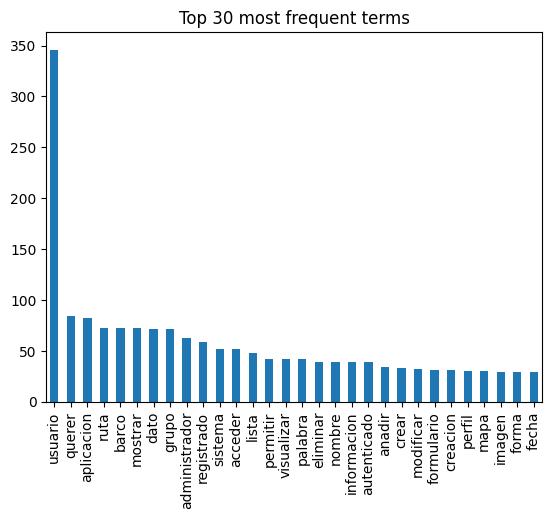

In [18]:
se_vocab_srt.head(30).plot.bar(
    title="Top 30 most frequent terms"
)

<Axes: title={'center': '30 términos menos frecuentes (con frecuencia >10)'}>

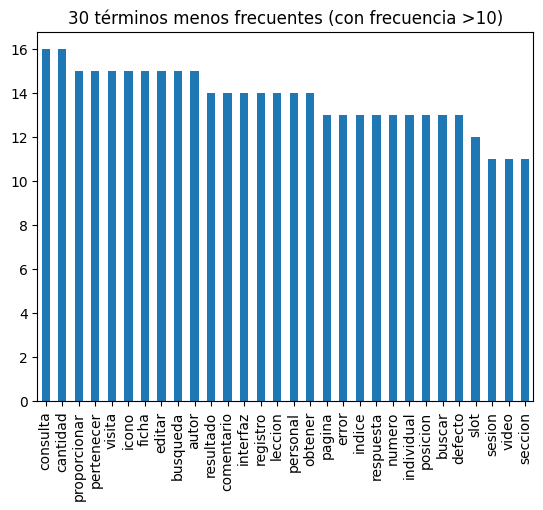

In [19]:
mask = se_vocab_srt > 10  # filtrar términos con frecuencia por debajo del umbral

se_vocab_srt[mask].tail(30).plot.bar(
    title="30 términos menos frecuentes (con frecuencia >10)"
)